# Matchstick Rotation Environment Demo

This notebook demonstrates the Matchstick Rotation environment where you rotate and position matchsticks.

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [5]:
env = gym.make("matchstick_rotation/easy", seed=42)
print(f"Position tolerance: {env.unwrapped.pos_tolerance}")
print(f"Angle tolerance: {env.unwrapped.ang_tolerance}°")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")

Position tolerance: 10
Angle tolerance: 15°
Action Space: FuncConditional(['move', 'stop'])
Available actions: ['move', 'stop']


## 2. Reset and View Initial State

Observation shape: (400, 400, 3)
Info: {}


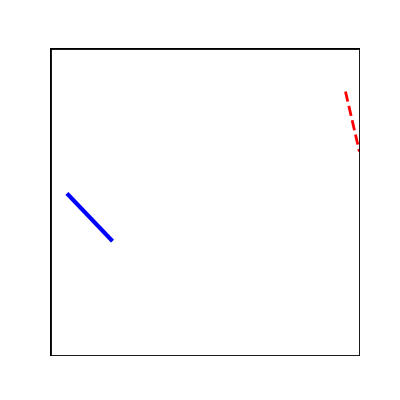


Task: Rotate and position matchsticks to match the target

Task Prompt:
You see a blue stick and a red target stick on a canvas. Your goal is to move and rotate the blue stick to match the red target stick. Unit moves are in an *unknown* scale (could be tiny or huge).

Available actions:
1. 'move': Translate by dx,dy units (any real number) and rotate by dθ° (any real number). Format: `('move', [dx, dy, dθ])`
2. 'stop': Submit your current stick as final. You win (+1) if your stick is within 10px and 15° of the target. Format: `('stop', 'stop')`

Please respond with exactly one action and its arguments in the specified format. For example:
- Move right by 2 units and rotate 45°: `('move', [2, 0, 45])`
- Move diagonally and rotate: `('move', [1.5, -0.8, 90])`
- Finalize the stick position: `('stop', 'stop')`


In [6]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Info: {info}")

display(Image.fromarray(obs))
print(f"\nTask: Rotate and position matchsticks to match the target")
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions

Action: ('move', [2.0, 1.5, 45.0])
Feedback: Action executed successfully.


user/launch/current/gymnasium/spaces/box.py:423: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


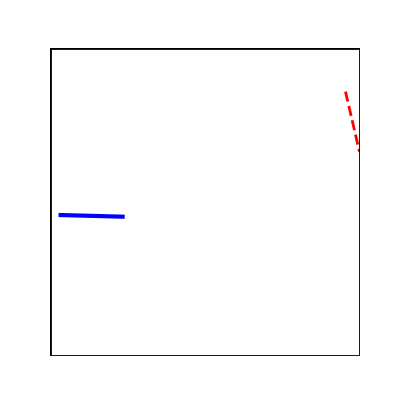

In [7]:
# Move and rotate the stick
action = "('move', [2.0, 1.5, 45.0])"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Feedback: {info.get('env_feedback', 'N/A')}")
display(Image.fromarray(obs))

## 4. Test Solver

Initial configuration:


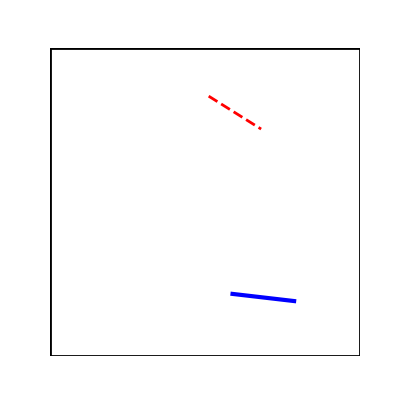


Solver generated 6 actions

Step 1: ('move', [0.0, 4.0, 0.0])


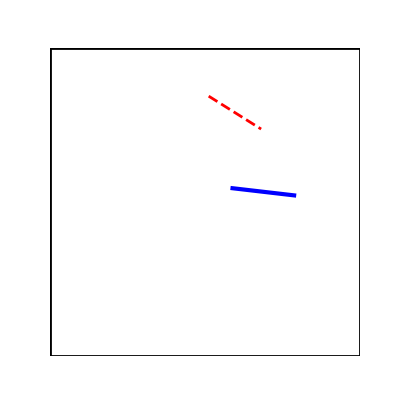


Step 2: ('move', [0.0, 3.0, 0.0])


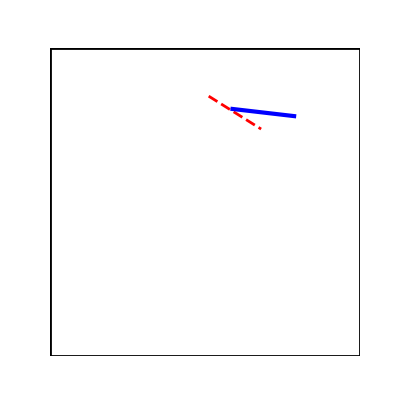


Step 3: ('move', [0.0, 2.0, 0.0])


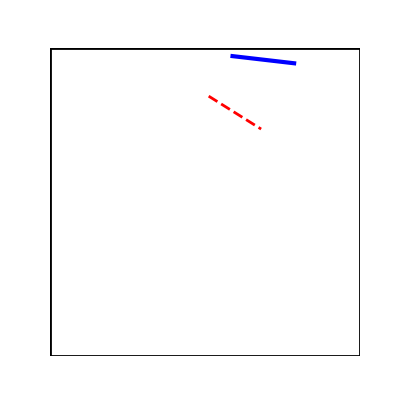


Step 4: ('move', [0.0, 1.0, 0.0])


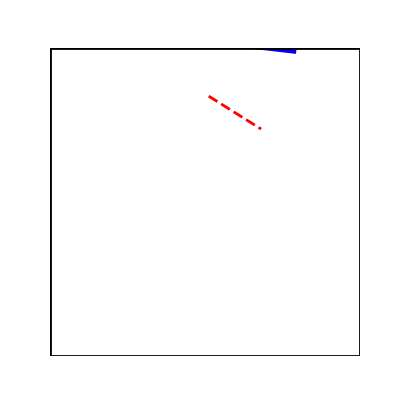


Step 5: ('move', [-1.1, -3.0, -25.6])


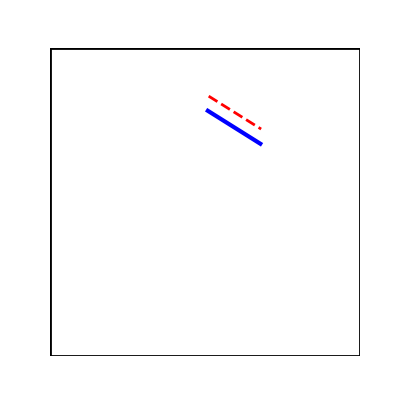


Step 6: ('stop', 'stop')


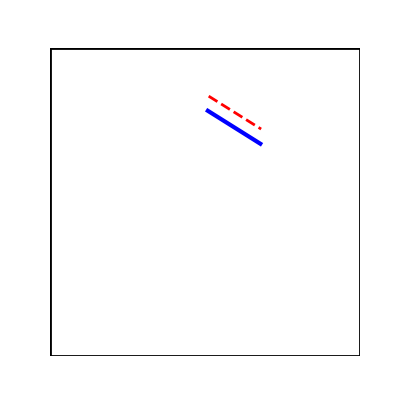


✓ Task complete! Reward: 1.0


In [8]:
env = gym.make("matchstick_rotation/easy", seed=100)
obs, info = env.reset()
print("Initial configuration:")
display(Image.fromarray(obs))

# Get solver actions
actions = env.solve()
print(f"\nSolver generated {len(actions)} actions")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {i+1}: {action}")
    display(Image.fromarray(obs))
    if terminated:
        print(f"\n✓ Task complete! Reward: {reward}")
        break

env.close()

## 5. Test Hard Difficulty (Stricter Tolerances)

Hard difficulty:
Position tolerance: 5 (vs easy: 10)
Angle tolerance: 10° (vs easy: 15°)


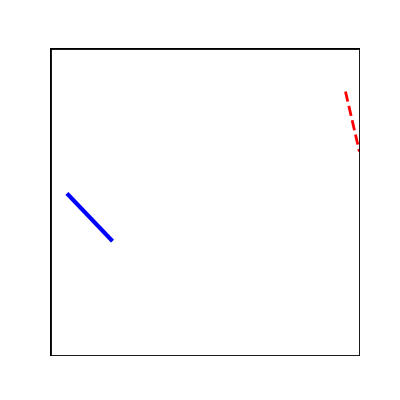


Solution: 6 actions
Reward: 1.0


user/launch/current/gymnasium/spaces/box.py:423: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [10]:
env_hard = gym.make("matchstick_rotation/hard", seed=42)
obs, info = env_hard.reset()
print(f"Hard difficulty:")
print(f"Position tolerance: {env_hard.unwrapped.pos_tolerance} (vs easy: 10)")
print(f"Angle tolerance: {env_hard.unwrapped.ang_tolerance}° (vs easy: 15°)")
display(Image.fromarray(obs))

# Get solution
actions = env_hard.solve()
print(f"\nSolution: {len(actions)} actions")
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    if terminated:
        print(f"Reward: {reward}")
        break

env_hard.close()